# Notebook 3 — Comparación de arquitecturas YOLO

**TP Visión por Computadora II — CEIA FIUBA**

Se comparan los tres modelos entrenados en métricas de detección, latencia y complejidad
para justificar la elección del modelo óptimo para el sistema de monitoreo en tiempo real.


In [23]:
import importlib
import os
import json
import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
import torch
import shutil
import time
from pathlib import Path
from collections import Counter, defaultdict, deque
from ultralytics import YOLO

EN_COLAB = importlib.util.find_spec("google.colab") is not None

plt.rcParams["figure.dpi"] = 120
sns.set_theme(style="whitegrid", palette="husl")

carpeta_datos = Path("data") if EN_COLAB else Path("../data")
carpeta_modelos = Path("models") if EN_COLAB else Path("../models")
carpeta_runs = Path("runs") if EN_COLAB else Path("../runs")

dispositivo = "cuda" if torch.cuda.is_available() else "cpu"
tamanio_imagen = 640 if dispositivo == "cuda" else 416
num_workers = 4 if dispositivo == "cuda" else 0

with open(carpeta_datos / "dataset_config.json") as f:
    config_dataset = json.load(f)

ruta_yaml_dataset = config_dataset["dataset_yaml"]
nombres_clases = config_dataset["class_names"]
cantidad_clases = config_dataset["num_classes"]

print(f"Dispositivo: {dispositivo}")
print(f"Clases: {nombres_clases}")


Dispositivo: cpu
Clases: ['Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest', 'machinery', 'vehicle']


In [24]:
import matplotlib.patches as mpatches

# Cargar resultados generados en la Parte 2
with open(carpeta_datos / "eval_results.json") as f:
    resultados_evaluacion = json.load(f)

with open(carpeta_datos / "latency_results.json") as f:
    resultados_latencia = json.load(f)

# Información de complejidad por modelo
info_modelos = {
    "YOLOv8n":  {"params_M": 3.2,  "flops_G": 8.7},
    "YOLOv8m":  {"params_M": 25.9, "flops_G": 78.9},
    "YOLOv11n": {"params_M": 2.6,  "flops_G": 6.5},
}

print("Resultados cargados:")
print(json.dumps(resultados_evaluacion, indent=2))

Resultados cargados:
{
  "YOLOv8n": {
    "map50": 0.7773,
    "map50_95": 0.4764,
    "precision": 0.8964,
    "recall": 0.6851,
    "val_time_s": 5.7
  },
  "YOLOv8m": {
    "map50": 0.8576,
    "map50_95": 0.5796,
    "precision": 0.9362,
    "recall": 0.7868,
    "val_time_s": 6.0
  },
  "YOLOv11n": {
    "map50": 0.7685,
    "map50_95": 0.4613,
    "precision": 0.8883,
    "recall": 0.698,
    "val_time_s": 5.8
  }
}


### Tabla comparativa general

In [25]:
filas_comparacion = []
for nombre_modelo in resultados_evaluacion:
    fila = {"Modelo": nombre_modelo}
    fila.update(resultados_evaluacion[nombre_modelo])
    if nombre_modelo in resultados_latencia:
        fila.update(resultados_latencia[nombre_modelo])
    if nombre_modelo in info_modelos:
        fila.update(info_modelos[nombre_modelo])
    filas_comparacion.append(fila)

tabla_comparacion = pd.DataFrame(filas_comparacion).set_index("Modelo")

columnas_display = ["map50", "map50_95", "precision", "recall", "mean_ms", "fps", "params_M", "flops_G"]
nombres_columnas = ["mAP50", "mAP50-95", "Precision", "Recall", "Latencia (ms)", "FPS", "Params (M)", "FLOPs (G)"]
tabla_display = tabla_comparacion[columnas_display].copy()
tabla_display.columns = nombres_columnas

print("=" * 70)
print("           COMPARACION DE MODELOS - Construction PPE Detection")
print("=" * 70)
print(tabla_display.to_string())

           COMPARACION DE MODELOS - Construction PPE Detection
           mAP50  mAP50-95  Precision  Recall  Latencia (ms)    FPS  Params (M)  FLOPs (G)
Modelo                                                                                    
YOLOv8n   0.7773    0.4764     0.8964  0.6851            8.3  119.9         3.2        8.7
YOLOv8m   0.8576    0.5796     0.9362  0.7868           10.3   97.4        25.9       78.9
YOLOv11n  0.7685    0.4613     0.8883  0.6980           10.3   97.2         2.6        6.5


### Visualización de métricas de detección

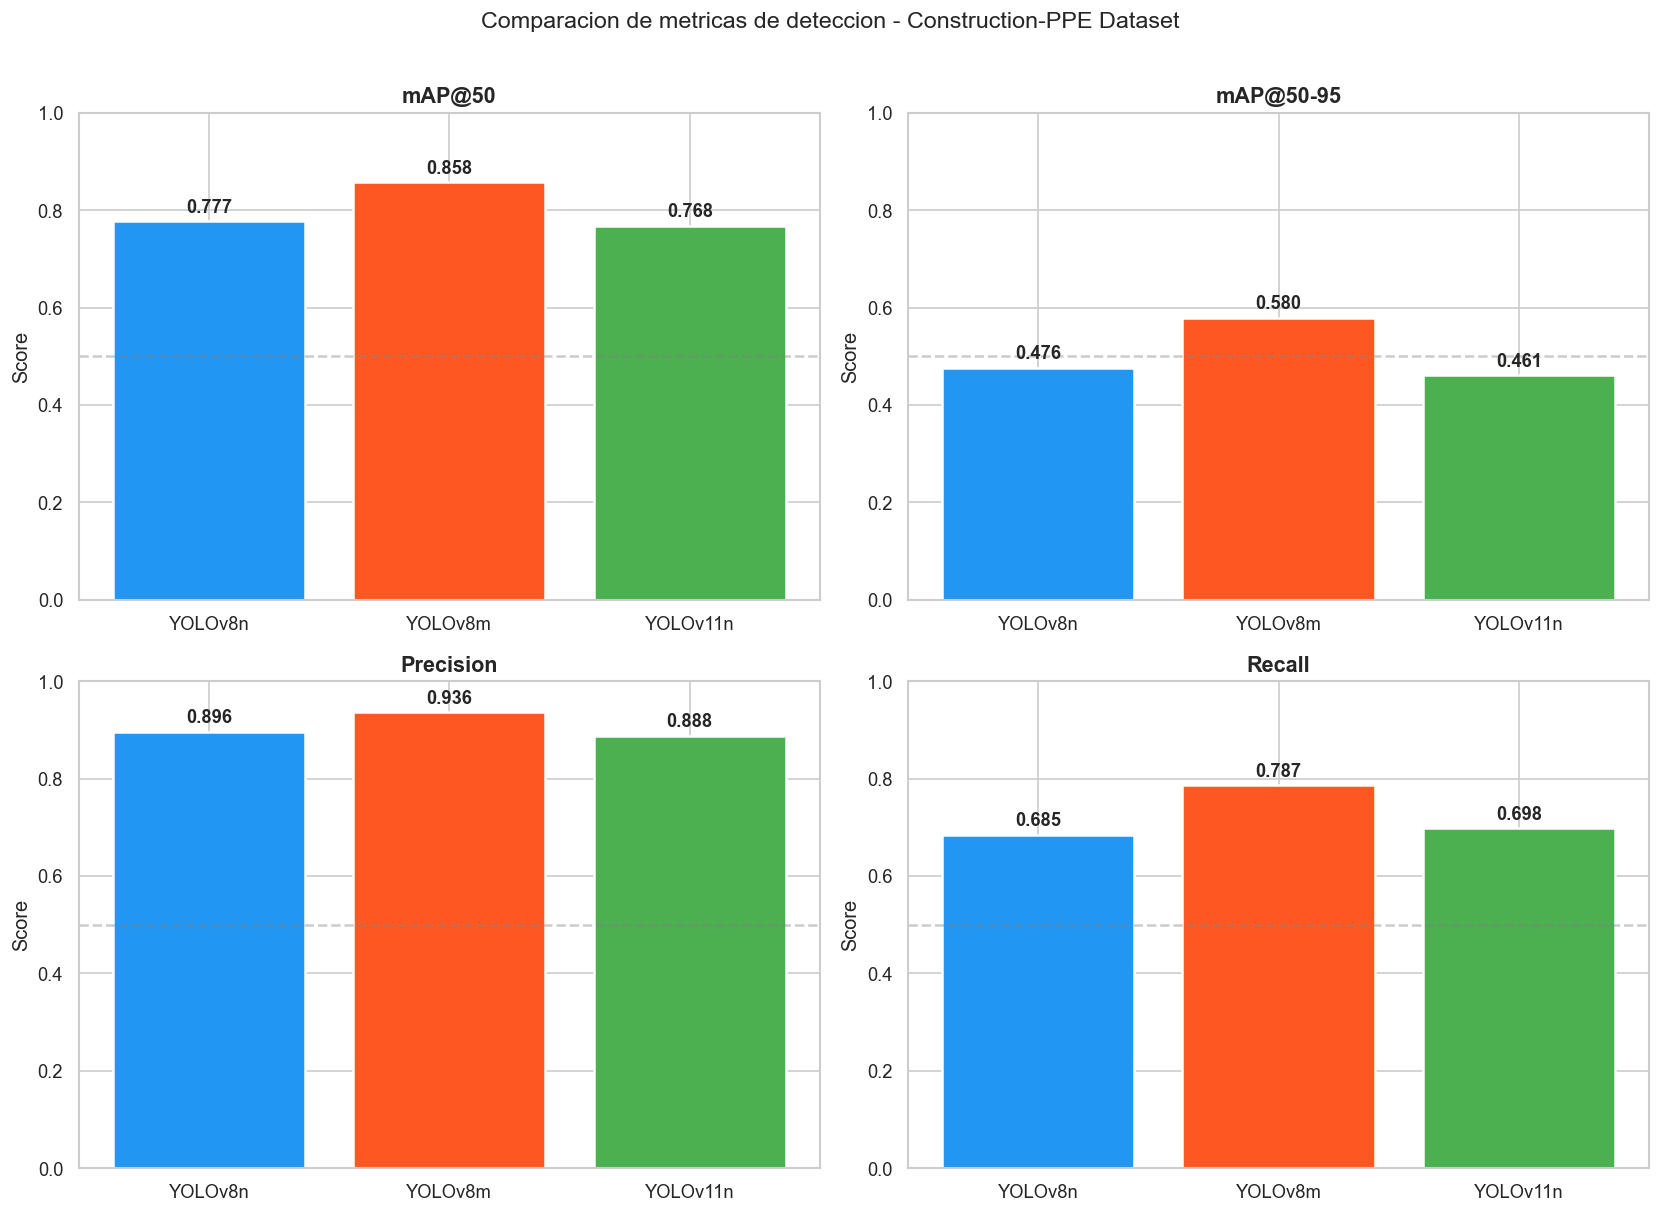

In [26]:
nombres_modelos = list(resultados_evaluacion.keys())
posiciones_x = np.arange(len(nombres_modelos))
colores_modelos = ["#2196F3", "#FF5722", "#4CAF50"]

fig, ejes = plt.subplots(2, 2, figsize=(14, 10))

metricas_a_graficar = [
    ("map50",    "mAP@50",    ejes[0, 0]),
    ("map50_95", "mAP@50-95", ejes[0, 1]),
    ("precision", "Precision", ejes[1, 0]),
    ("recall",   "Recall",     ejes[1, 1]),
]

for clave_metrica, etiqueta_metrica, eje in metricas_a_graficar:
    valores = [resultados_evaluacion[m].get(clave_metrica, 0) for m in nombres_modelos]
    barras = eje.bar(nombres_modelos, valores, color=colores_modelos[:len(nombres_modelos)],
                     edgecolor="white", linewidth=1.5)
    eje.set_title(etiqueta_metrica, fontsize=13, fontweight="bold")
    eje.set_ylim(0, 1.0)
    eje.set_ylabel("Score")
    eje.axhline(y=0.5, color="gray", linestyle="--", alpha=0.4)
    for barra, val in zip(barras, valores):
        eje.text(barra.get_x() + barra.get_width() / 2, val + 0.01, f"{val:.3f}",
                 ha="center", va="bottom", fontsize=11, fontweight="bold")

plt.suptitle("Comparacion de metricas de deteccion - Construction-PPE Dataset", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(carpeta_datos / "comparison_metrics.png", bbox_inches="tight", dpi=150)
plt.show()

### Trade-off velocidad vs. precisión

El tamaño del punto representa la cantidad de parámetros del modelo. Las líneas punteadas
delimitan la zona de despliegue práctico (FPS > 15 y mAP50 > 0.6).

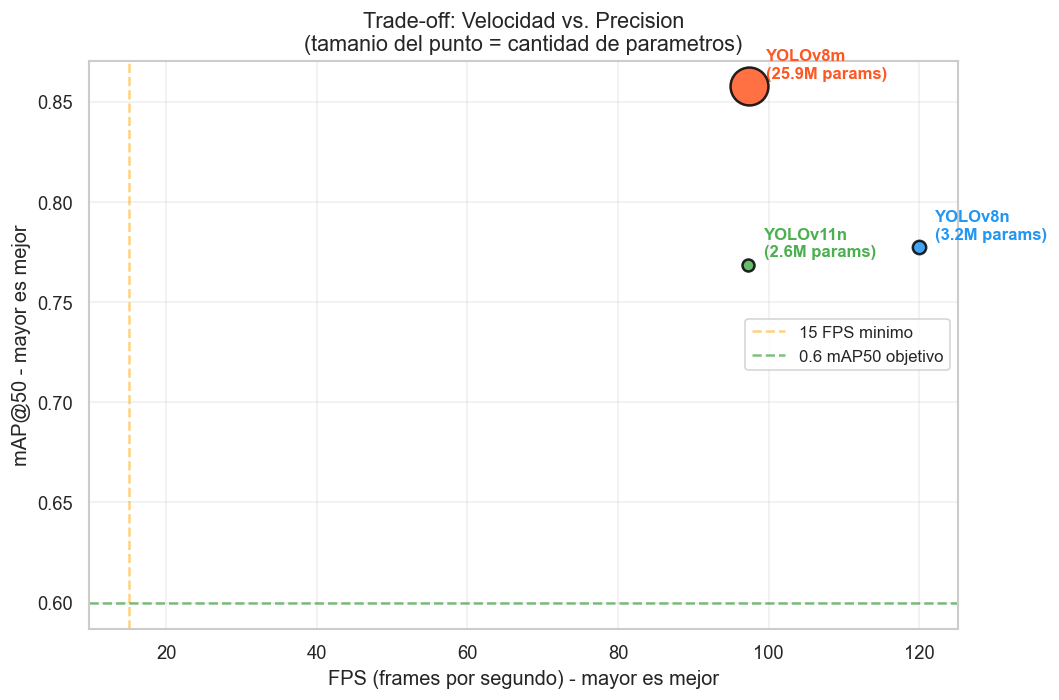

In [27]:
fig, eje = plt.subplots(figsize=(9, 6))

for i, nombre_modelo in enumerate(nombres_modelos):
    if nombre_modelo not in resultados_latencia:
        continue
    fps_modelo = resultados_latencia[nombre_modelo]["fps"]
    map50_modelo = resultados_evaluacion[nombre_modelo]["map50"]
    params_modelo = info_modelos.get(nombre_modelo, {}).get("params_M", 5)

    eje.scatter(fps_modelo, map50_modelo, s=params_modelo * 20, color=colores_modelos[i],
                alpha=0.85, edgecolors="black", linewidth=1.5, zorder=5)
    eje.annotate(f"{nombre_modelo}\n({params_modelo}M params)",
                 xy=(fps_modelo, map50_modelo), xytext=(10, 5), textcoords="offset points",
                 fontsize=10, fontweight="bold", color=colores_modelos[i])

eje.set_xlabel("FPS (frames por segundo) - mayor es mejor", fontsize=12)
eje.set_ylabel("mAP@50 - mayor es mejor", fontsize=12)
eje.set_title("Trade-off: Velocidad vs. Precision\n(tamanio del punto = cantidad de parametros)", fontsize=13)
eje.grid(True, alpha=0.3)

eje.axvline(x=15, color="orange", linestyle="--", alpha=0.5, label="15 FPS minimo")
eje.axhline(y=0.6, color="green", linestyle="--", alpha=0.5, label="0.6 mAP50 objetivo")
eje.legend(fontsize=10)

plt.tight_layout()
plt.savefig(carpeta_datos / "speed_accuracy_tradeoff.png", bbox_inches="tight", dpi=150)
plt.show()

### Curvas de entrenamiento

Se comparan las curvas de mAP@50 y box loss (train y validación) para cada modelo.

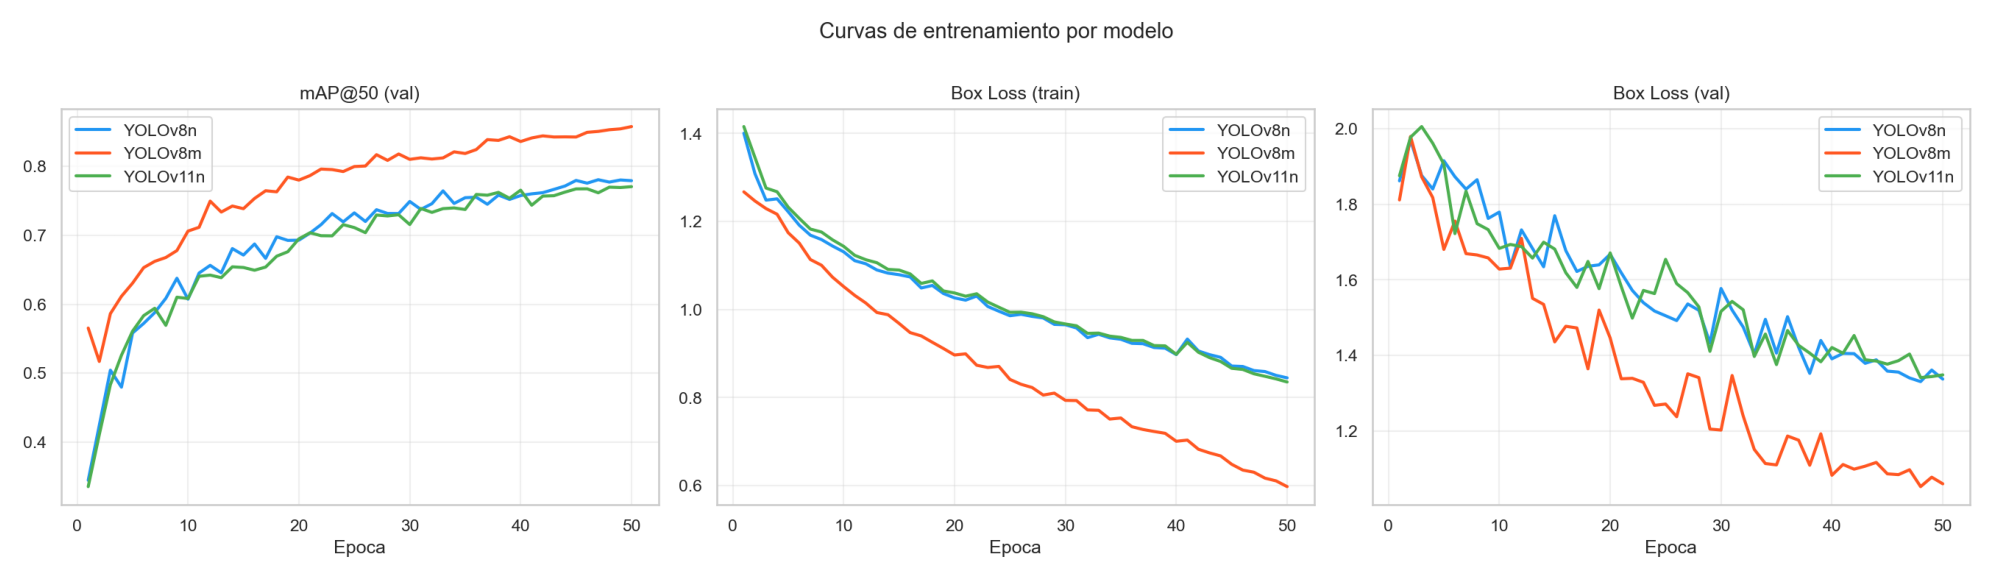

In [28]:
# Curvas generadas por la notebook 02 durante el entrenamiento
img_curvas = plt.imread(str(carpeta_datos / "training_curves.png"))
fig, eje = plt.subplots(figsize=(18, 5))
eje.imshow(img_curvas)
eje.axis("off")
plt.tight_layout()
plt.show()


### Métricas por clase del mejor modelo

Se re-evalúa el modelo con mayor mAP50 para obtener el AP@50 desglosado por clase.

In [29]:
# Determinar el mejor modelo segun mAP50
nombre_mejor_modelo = max(resultados_evaluacion, key=lambda m: resultados_evaluacion[m].get("map50", 0))

mapa_archivos_modelos = {
    "YOLOv8n":  carpeta_modelos / "yolov8n_best.pt",
    "YOLOv8m":  carpeta_modelos / "yolov8m_best.pt",
    "YOLOv11n": carpeta_modelos / "yolov11n_best.pt",
}
ruta_mejor_modelo = mapa_archivos_modelos[nombre_mejor_modelo]

print(f"Mejor modelo: {nombre_mejor_modelo} (mAP50 = {resultados_evaluacion[nombre_mejor_modelo]['map50']:.4f})")

modelo_mejor = YOLO(str(ruta_mejor_modelo))

metricas_por_clase = modelo_mejor.val(
    data=ruta_yaml_dataset,
    device=dispositivo,
    workers=num_workers,
    verbose=True,
)

Mejor modelo: YOLOv8m (mAP50 = 0.8576)
Ultralytics 8.4.33 🚀 Python-3.11.13 torch-2.11.0 CPU (Apple M3 Max)
Model summary (fused): 93 layers, 25,845,550 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 353.9±468.2 MB/s, size: 51.5 KB)
val: Scanning /Users/mferrari/git/fiuba/vision_computadora_2/data/construction-ppe/valid/labels.cache... 114 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 114/114 95.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 5.6s/it 44.7s6.8sss
                   all        114        697      0.936      0.787      0.866      0.594
               Hardhat         42         79      0.956      0.823      0.918      0.626
                  Mask         19         21      0.981      0.952      0.961      0.752
            NO-Hardhat         37         69      0.904      0.667       0.79      0.471
               NO-Mask         44         74      0.947

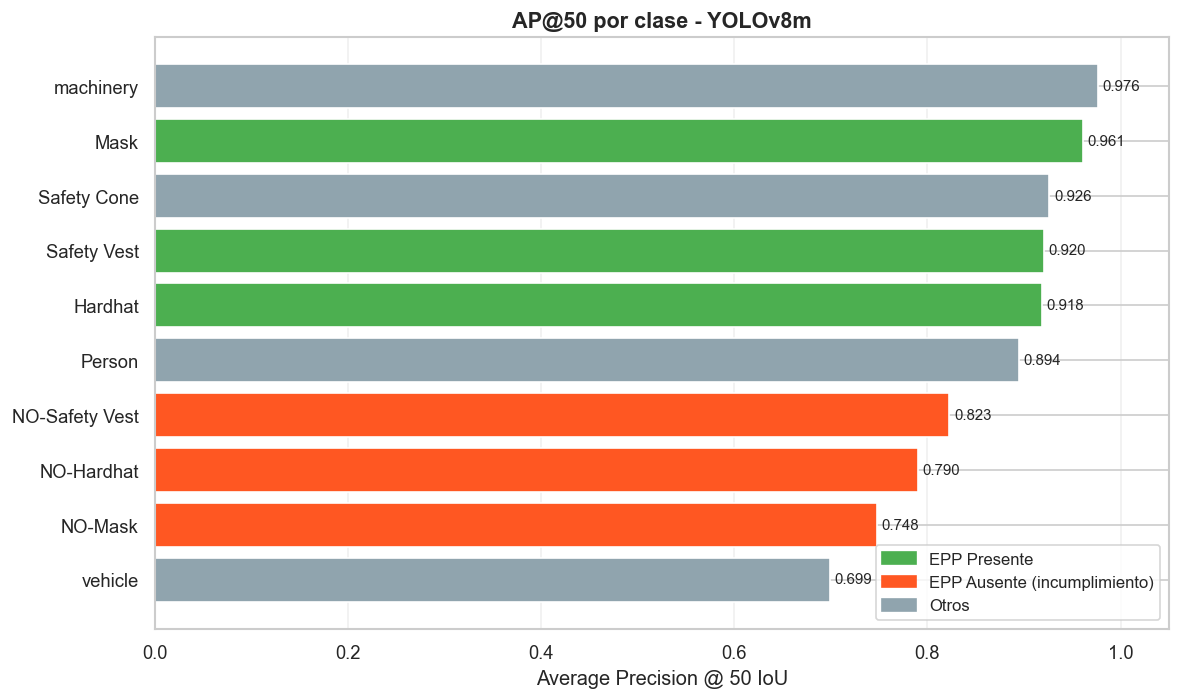

In [30]:
try:
    ap_por_clase = metricas_por_clase.box.ap50

    df_por_clase = pd.DataFrame({
        "Clase": nombres_clases[:len(ap_por_clase)],
        "AP@50": np.round(ap_por_clase, 4),
    }).sort_values("AP@50", ascending=True)

    def color_segun_clase(nombre_clase):
        if nombre_clase.startswith("NO-"):
            return "#FF5722"
        elif nombre_clase in {"Hardhat", "Mask", "Safety Vest"}:
            return "#4CAF50"
        return "#90A4AE"

    colores_barras = [color_segun_clase(c) for c in df_por_clase["Clase"]]

    fig, eje = plt.subplots(figsize=(10, 6))
    barras = eje.barh(df_por_clase["Clase"], df_por_clase["AP@50"],
                      color=colores_barras, edgecolor="white", linewidth=1)

    for barra, val in zip(barras, df_por_clase["AP@50"]):
        eje.text(val + 0.005, barra.get_y() + barra.get_height() / 2,
                 f"{val:.3f}", va="center", fontsize=9)

    parches_leyenda = [
        mpatches.Patch(color="#4CAF50", label="EPP Presente"),
        mpatches.Patch(color="#FF5722", label="EPP Ausente (incumplimiento)"),
        mpatches.Patch(color="#90A4AE", label="Otros"),
    ]
    eje.legend(handles=parches_leyenda, loc="lower right", fontsize=10)
    eje.set_xlim(0, 1.05)
    eje.set_xlabel("Average Precision @ 50 IoU")
    eje.set_title(f"AP@50 por clase - {nombre_mejor_modelo}", fontsize=13, fontweight="bold")
    eje.grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.savefig(carpeta_datos / "ap_per_class.png", bbox_inches="tight", dpi=150)
    plt.show()
except Exception as e:
    print(f"No se pudo extraer AP por clase: {e}")

### Predicciones del mejor modelo sobre imágenes de validación

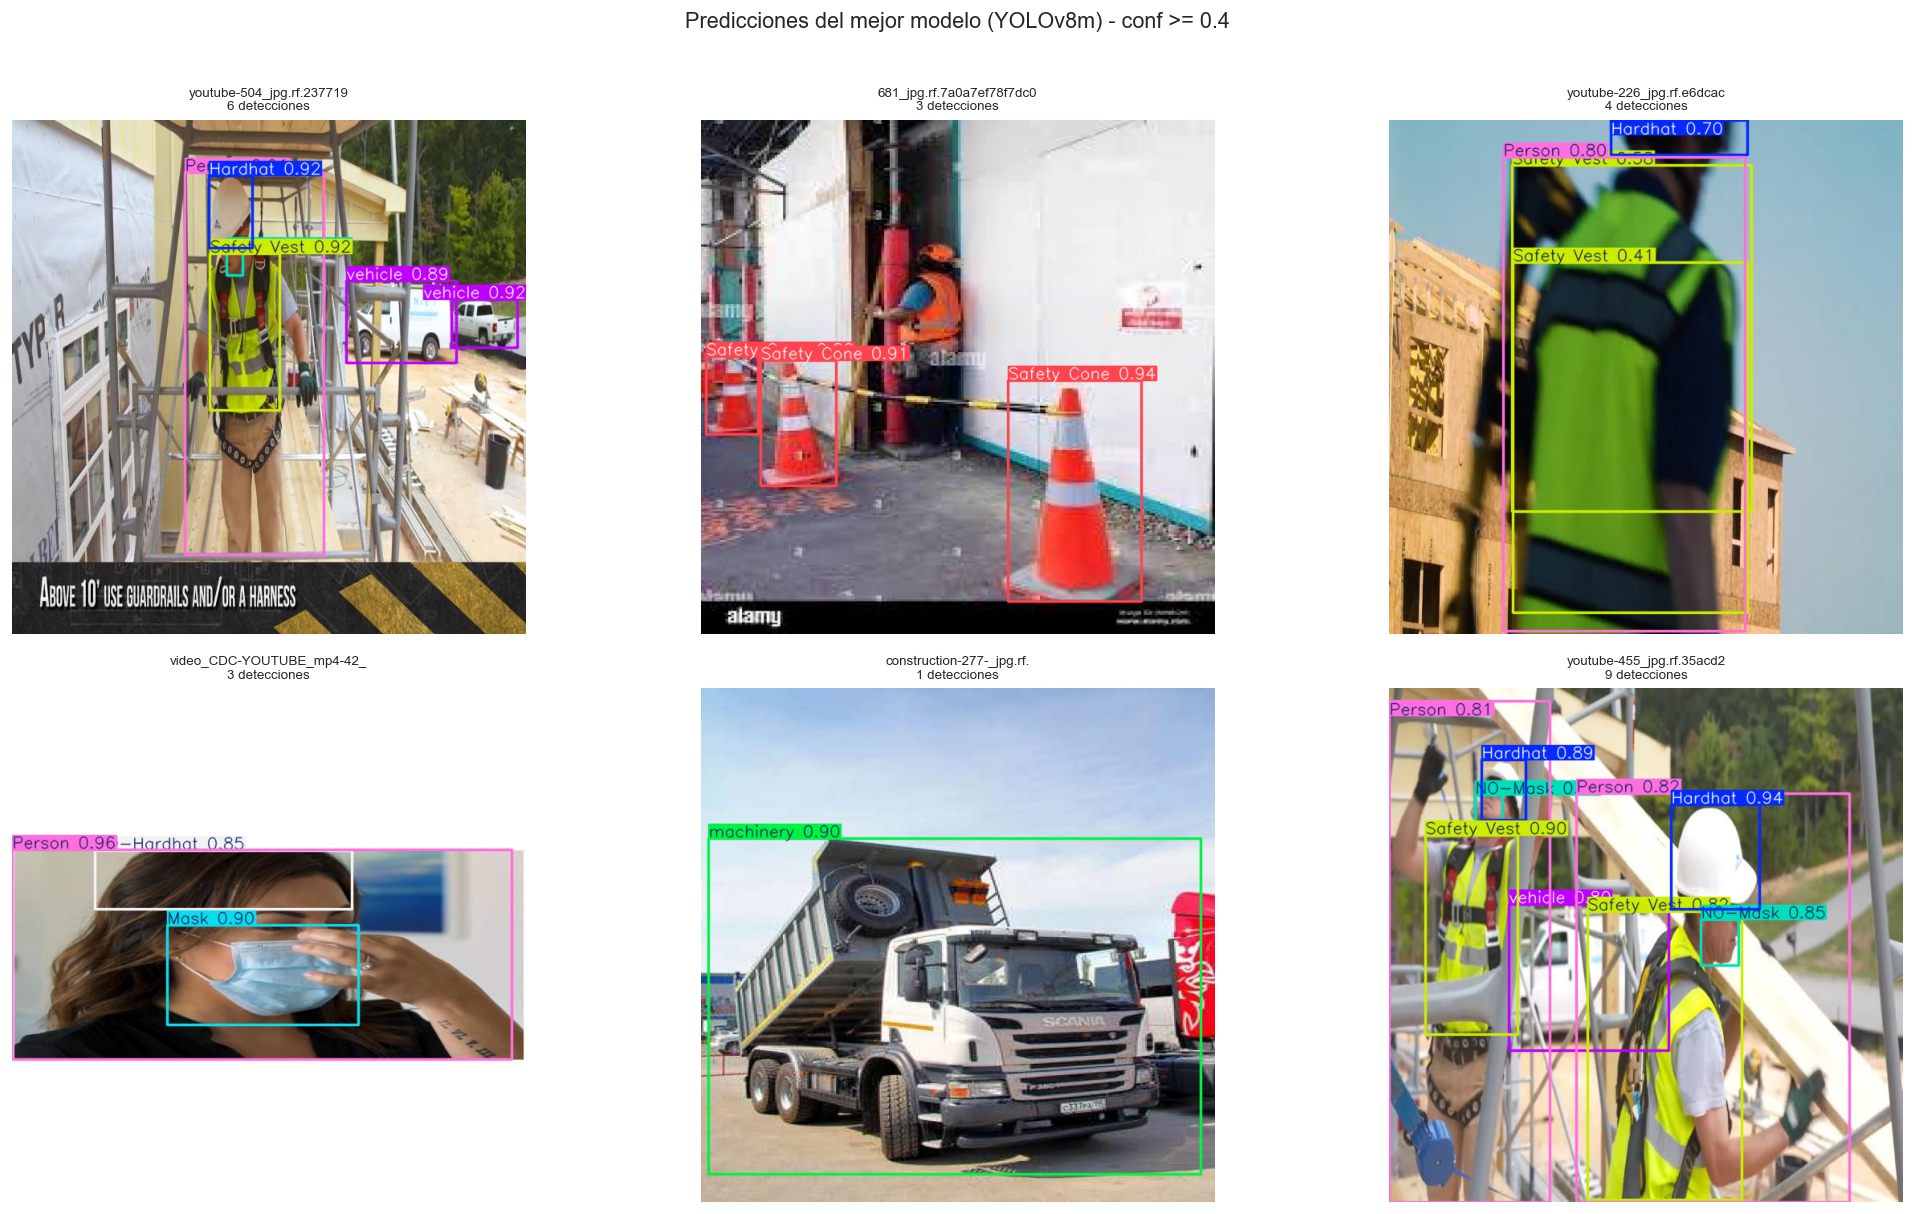

In [31]:
ruta_dataset_yaml = Path(ruta_yaml_dataset).parent
imagenes_validacion = list((ruta_dataset_yaml / "valid" / "images").glob("*.jpg"))
random.seed(2024)
muestras_validacion = random.sample(imagenes_validacion, min(6, len(imagenes_validacion)))

fig, ejes = plt.subplots(2, 3, figsize=(18, 10))
ejes = ejes.flatten()

for eje, ruta_img in zip(ejes, muestras_validacion):
    resultados_pred = modelo_mejor.predict(str(ruta_img), conf=0.4, verbose=False, device=dispositivo)
    imagen_anotada = resultados_pred[0].plot()
    imagen_rgb = cv2.cvtColor(imagen_anotada, cv2.COLOR_BGR2RGB)
    eje.imshow(imagen_rgb)
    eje.axis("off")
    cantidad_detecciones = len(resultados_pred[0].boxes)
    eje.set_title(f"{ruta_img.name[:25]}\n{cantidad_detecciones} detecciones", fontsize=8)

plt.suptitle(f"Predicciones del mejor modelo ({nombre_mejor_modelo}) - conf >= 0.4", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(carpeta_datos / "best_model_predictions.png", bbox_inches="tight", dpi=150)
plt.show()

### Justificación del modelo seleccionado

In [32]:
print("=" * 65)
print("  ANALISIS COMPARATIVO - Sistema de Monitoreo EPP")
print("=" * 65)

for nombre_modelo in resultados_evaluacion:
    e = resultados_evaluacion[nombre_modelo]
    l = resultados_latencia.get(nombre_modelo, {})
    params = info_modelos.get(nombre_modelo, {}).get("params_M", "?")

    print(f"\n  {nombre_modelo}")
    print(f"   Parametros:   {params}M")
    print(f"   mAP50:        {e['map50']:.4f}")
    print(f"   mAP50-95:     {e['map50_95']:.4f}")
    print(f"   Precision:    {e['precision']:.4f}")
    print(f"   Recall:       {e['recall']:.4f}")
    print(f"   Latencia:     {l.get('mean_ms', '?')} ms ({l.get('fps', '?')} FPS)")

print()
print("=" * 65)
print("  CONCLUSION")
print("=" * 65)
print(f"""
Para un sistema de monitoreo de EPP en tiempo real:

- YOLOv8n: El mas rapido (menor latencia). Ideal para edge devices
  o cuando la velocidad es critica. Trade-off: menor mAP.

- YOLOv8m: El mas preciso entre los v8, pero el mas lento.
  Recomendado si se dispone de GPU y se prioriza precision.

- YOLOv11n: Nueva arquitectura con menos parametros que v8n
  pero arquitectura mejorada. Mejor balance velocidad/precision
  en arquitecturas recientes.

Modelo seleccionado para la demo: {nombre_mejor_modelo}
  (mayor mAP50 entre los entrenados)
""")

  ANALISIS COMPARATIVO - Sistema de Monitoreo EPP

  YOLOv8n
   Parametros:   3.2M
   mAP50:        0.7773
   mAP50-95:     0.4764
   Precision:    0.8964
   Recall:       0.6851
   Latencia:     8.3 ms (119.9 FPS)

  YOLOv8m
   Parametros:   25.9M
   mAP50:        0.8576
   mAP50-95:     0.5796
   Precision:    0.9362
   Recall:       0.7868
   Latencia:     10.3 ms (97.4 FPS)

  YOLOv11n
   Parametros:   2.6M
   mAP50:        0.7685
   mAP50-95:     0.4613
   Precision:    0.8883
   Recall:       0.6980
   Latencia:     10.3 ms (97.2 FPS)

  CONCLUSION

Para un sistema de monitoreo de EPP en tiempo real:

- YOLOv8n: El mas rapido (menor latencia). Ideal para edge devices
  o cuando la velocidad es critica. Trade-off: menor mAP.

- YOLOv8m: El mas preciso entre los v8, pero el mas lento.
  Recomendado si se dispone de GPU y se prioriza precision.

- YOLOv11n: Nueva arquitectura con menos parametros que v8n
  pero arquitectura mejorada. Mejor balance velocidad/precision
  en arquitectu